# B6 (Partie 5) — Empreinte carbone de l'entraînement avec CodeCarbon

**Prérequis** : TP3/TP4 exécutés — checkpoint `ae_v3_best.keras` disponible.

Ce TP applique **CodeCarbon** pour répondre à la question production :
> *Combien coûte, en CO₂, l'entraînement puis l'usage répété de ce modèle ?*

La **Green AI**, ce n'est pas s'interdire d'entraîner — c'est **quantifier avant d'arbitrer** :
mesurer l'énergie réellement consommée (kWh), la traduire en émissions (gCO₂eq) selon
le mix électrique local, et comparer ce coût à la valeur métier obtenue.

| § | Analyse | Outil |
|---|---|---|
| §1 | Empreinte d'un entraînement complet | `EmissionsTracker` |
| §2 | Empreinte de l'inférence en production | `EmissionsTracker` |
| §3 | Arbitrage architecture ↔ empreinte carbone | comparaison multi-runs |
| §4 | Effet du mix énergétique (le lieu compte autant que l'usage) | facteurs d'intensité carbone |
| §5 | Mise en perspective, limites et bonnes pratiques | équivalences concrètes |


## §0 — Setup

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import codecarbon
from codecarbon import EmissionsTracker

sys.path.insert(0, str(Path("src")))
from indusense.vision.dataset import load_train_val, load_test
from indusense.vision.model   import build_autoencoder, mse_ssim_loss, compression_ratio
from indusense.vision.train   import train
from indusense.vision.anomaly import reconstruction_errors

BOTTLE_ROOT = Path("bottle")
SEED        = 42
Path("figures").mkdir(exist_ok=True)
Path("emissions").mkdir(exist_ok=True)

X_train, X_val = load_train_val(BOTTLE_ROOT, val_ratio=0.2, seed=SEED)
X_test, y_test, test_classes = load_test(BOTTLE_ROOT)

print(f"CodeCarbon {codecarbon.__version__}  |  TF {tf.__version__}")
print(f"GPU disponible : {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Train={X_train.shape[0]}  Val={X_val.shape[0]}  Test={X_test.shape[0]}")


CodeCarbon 3.2.9  |  TF 2.21.0


GPU disponible : False
Train=168  Val=41  Test=83


## §1 — Empreinte d'un entraînement complet

`EmissionsTracker` échantillonne en continu la puissance CPU (RAPL/Intel ou estimation
via `cpuinfo`), GPU (`nvidia-ml`) et RAM (estimation par Go installé), intègre dans le
temps pour obtenir une énergie (kWh), puis multiplie par l'intensité carbone du mix
électrique **détecté automatiquement via géolocalisation IP** pour obtenir des gCO₂eq.

> ⚠ `measure_power_secs` fixe la fréquence d'échantillonnage. Pour un entraînement de
> quelques secondes comme ici, on le réduit à 1s — en production sur un job de plusieurs
> heures, la valeur par défaut (15s) suffit et réduit l'overhead de mesure.

In [2]:
tracker_train = EmissionsTracker(
    project_name="tp6_train_ae_v3",
    output_dir="emissions",
    measure_power_secs=1,
    log_level="error",
    save_to_file=True,
)

model_train_demo = build_autoencoder(filters=(32, 64, 128, 64))
loss_fn = mse_ssim_loss(alpha=0.8)

tracker_train.start()
history_demo = train(
    model_train_demo, X_train, X_val,
    epochs=10, batch_size=16, loss=loss_fn,
    run_name="tp6_ae_v3_demo",
    checkpoint_path=None,
    use_mlflow=False,
)
emissions_train_kg = tracker_train.stop()
data_train = tracker_train.final_emissions_data

print(f"Émissions   : {emissions_train_kg * 1000:.4f} gCO2eq")
print(f"Énergie     : {data_train.energy_consumed * 1000:.3f} Wh"
      f"  (CPU={data_train.cpu_energy*1000:.3f}  GPU={data_train.gpu_energy*1000:.3f}"
      f"  RAM={data_train.ram_energy*1000:.3f})")
print(f"Durée       : {data_train.duration:.1f} s  |  {history_demo.history['val_loss'].__len__()} epochs")
print(f"val_loss final : {history_demo.history['val_loss'][-1]:.5f}")
print(f"Mix détecté : {data_train.country_name} ({data_train.country_iso_code})")


[codecarbon WARNING @ 15:36:58] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/10


 1/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - loss: 0.2143

 2/11 ━━━━━━━━━━━━━━━━━━━━ 5s 611ms/step - loss: 0.2144

 3/11 ━━━━━━━━━━━━━━━━━━━━ 5s 626ms/step - loss: 0.2143

...

10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - loss: 0.0522

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - loss: 0.0520

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 953ms/step - loss: 0.0520 - val_loss: 0.0493 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 10.


Émissions   : 0.0515 gCO2eq
Énergie     : 0.918 Wh  (CPU=0.491  GPU=0.163  RAM=0.264)
Durée       : 94.8 s  |  10 epochs
val_loss final : 0.04929
Mix détecté : France (FRA)


## §2 — Empreinte de l'inférence en production

Un modèle s'entraîne **une fois** mais s'utilise en inférence **des milliers de fois**.
On mesure ici le coût d'un passage complet du jeu de test dans le modèle déjà entraîné
(`ae_v3_best.keras`, issu du TP4 — pas de ré-entraînement), puis on extrapole à un
volume de production réaliste pour comparer les deux régimes de coût.

In [3]:
custom_loss = mse_ssim_loss(alpha=0.8)
model_v3 = keras.models.load_model(
    "checkpoints/ae_v3_best.keras",
    custom_objects={custom_loss.__name__: custom_loss},
)

N_REPEATS = 40  # simule ~40 x le test set pour obtenir un signal mesurable
tracker_infer = EmissionsTracker(
    project_name="tp6_infer_ae_v3",
    output_dir="emissions",
    measure_power_secs=1,
    log_level="error",
    save_to_file=True,
)

tracker_infer.start()
for _ in range(N_REPEATS):
    _ = reconstruction_errors(model_v3, X_test, batch_size=16)
emissions_infer_kg = tracker_infer.stop()
data_infer = tracker_infer.final_emissions_data

n_images_mesure   = N_REPEATS * len(X_test)
gco2_par_image    = (emissions_infer_kg * 1000) / n_images_mesure
gco2_par_train    = emissions_train_kg * 1000

print(f"Images scorées (mesure) : {n_images_mesure}")
print(f"Émissions totales       : {emissions_infer_kg * 1000:.4f} gCO2eq")
print(f"Coût par image          : {gco2_par_image:.6f} gCO2eq")
print()

for volume_jour in [1_000, 100_000, 1_000_000]:
    cout_an = gco2_par_image * volume_jour * 365
    print(f"{volume_jour:>9,} images/jour → {cout_an/1000:.2f} kgCO2eq / an "
          f"({cout_an / gco2_par_train:.0f}x le coût de l'entraînement §1)")


Images scorées (mesure) : 3320
Émissions totales       : 0.0089 gCO2eq
Coût par image          : 0.000003 gCO2eq

    1,000 images/jour → 0.00 kgCO2eq / an (19x le coût de l'entraînement §1)
  100,000 images/jour → 0.10 kgCO2eq / an (1908x le coût de l'entraînement §1)
1,000,000 images/jour → 0.98 kgCO2eq / an (19077x le coût de l'entraînement §1)


## §3 — Arbitrage architecture ↔ empreinte carbone

Trois architectures d'auto-encodeur (mêmes données, mêmes epochs) : un goulot large
(quasi-identité), un goulot compact (celui retenu en TP3/TP4) et un goulot très étroit.
Chaque entraînement est tracké indépendamment — on compare **qualité (val_loss, ratio de
compression)** et **coût carbone** sur un pied d'égalité.

In [4]:
ARCHS = {
    "large (32,64,128)":       (32, 64, 128),
    "compact (32,64,128,64)":  (32, 64, 128, 64),
    "etroit (32,64,128,64,32)": (32, 64, 128, 64, 32),
}

EPOCHS_ARCH = 8
results_arch = []

for name, filters in ARCHS.items():
    print(f"--- {name} ---")
    m = build_autoencoder(filters=filters)
    ratio = compression_ratio(m)

    tracker = EmissionsTracker(
        project_name=f"tp6_arch_{name.split()[0]}",
        output_dir="emissions",
        measure_power_secs=1,
        log_level="error",
        save_to_file=True,
    )
    tracker.start()
    hist = train(
        m, X_train, X_val,
        epochs=EPOCHS_ARCH, batch_size=16, loss=mse_ssim_loss(alpha=0.8),
        run_name=f"tp6_{name}", checkpoint_path=None, use_mlflow=False,
    )
    em_kg = tracker.stop()
    data  = tracker.final_emissions_data

    results_arch.append({
        "architecture":  name,
        "n_params":      m.count_params(),
        "ratio_compression": ratio,
        "val_loss":      hist.history["val_loss"][-1],
        "gco2eq":        em_kg * 1000,
        "energie_Wh":    data.energy_consumed * 1000,
        "duree_s":       data.duration,
    })

df_arch = pd.DataFrame(results_arch).sort_values("gco2eq")
df_arch


--- large (32,64,128) ---


Epoch 1/8


 1/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.2143

 2/11 ━━━━━━━━━━━━━━━━━━━━ 7s 830ms/step - loss: 0.2145

 3/11 ━━━━━━━━━━━━━━━━━━━━ 6s 838ms/step - loss: 0.2143

...

10/11 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - loss: 0.0878

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0872

11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0872 - val_loss: 0.0745 - learning_rate: 0.0010


Restoring model weights from the end of the best epoch: 8.


,architecture,n_params,ratio_compression,val_loss,gco2eq,energie_Wh,duree_s
0,"large (32,64,128)",186371,1.5,0.042106,0.046102,0.822683,86.834418
1,"compact (32,64,128,64)",334019,12.0,0.099523,0.059920,1.069259,101.035879
2,"etroit (32,64,128,64,32)",370979,96.0,0.074525,0.106732,1.904608,173.623081


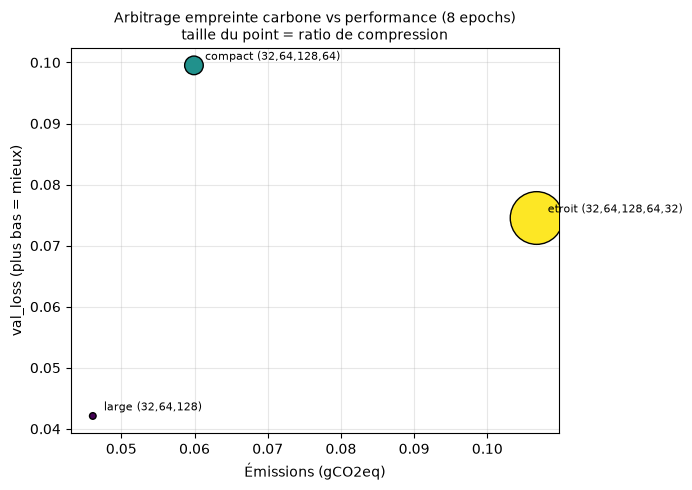

Sauvegardé : figures/tp6_01_arbitrage_gco2_vs_loss.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df_arch["gco2eq"], df_arch["val_loss"],
                s=df_arch["ratio_compression"] * 15, c=range(len(df_arch)),
                cmap="viridis", edgecolor="black", zorder=3)
for _, row in df_arch.iterrows():
    ax.annotate(row["architecture"], (row["gco2eq"], row["val_loss"]),
                textcoords="offset points", xytext=(8, 4), fontsize=8)
ax.set_xlabel("Émissions (gCO2eq)")
ax.set_ylabel("val_loss (plus bas = mieux)")
ax.set_title(f"Arbitrage empreinte carbone vs performance ({EPOCHS_ARCH} epochs)\n"
             "taille du point = ratio de compression", fontsize=10)
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig("figures/tp6_01_arbitrage_gco2_vs_loss.png", bbox_inches="tight", dpi=100)
plt.show()
print("Sauvegardé : figures/tp6_01_arbitrage_gco2_vs_loss.png")


## §4 — Effet du mix énergétique : le lieu compte autant que l'usage

`EmissionsTracker` a détecté le pays d'exécution ci-dessus et appliqué son intensité
carbone (gCO₂eq/kWh) — propre à son mix électrique. **L'énergie consommée (kWh) est un
fait physique universel ; l'empreinte carbone (gCO₂eq) qu'on en tire dépend entièrement
d'*où* et *quand* cette énergie a été produite.**

On reprend l'énergie mesurée en §1 (kWh, fixe) et on la convertit avec des intensités
carbone moyennes 2023 publiées (RTE, Ember, electricityMaps — ordres de grandeur
pédagogiques, pas des valeurs temps réel).

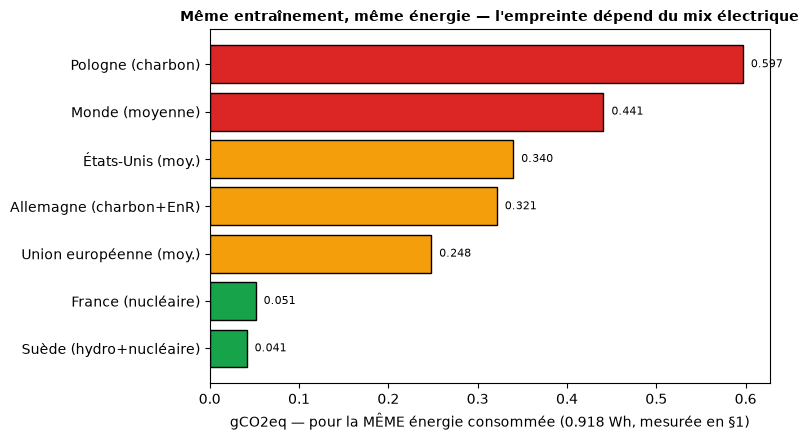

Sauvegardé : figures/tp6_02_mix_energetique.png

Ratio pire/meilleur mix : 14.4x pour une énergie strictement identique.


In [6]:
# gCO2eq / kWh — moyennes annuelles 2023 par mix électrique (ordres de grandeur)
INTENSITE_CARBONE = {
    "France (nucléaire)":        56,
    "Suède (hydro+nucléaire)":   45,
    "Union européenne (moy.)":  270,
    "Allemagne (charbon+EnR)":  350,
    "États-Unis (moy.)":        370,
    "Pologne (charbon)":        650,
    "Monde (moyenne)":          480,
}

energie_kwh = data_train.energy_consumed  # mesurée en §1, fixe pour toute la comparaison

df_mix = pd.DataFrame([
    {"mix": mix, "intensite_gco2_kwh": intensite, "gco2eq": energie_kwh * intensite}
    for mix, intensite in INTENSITE_CARBONE.items()
]).sort_values("gco2eq")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#16A34A" if v < 100 else "#F59E0B" if v < 400 else "#DC2626"
          for v in df_mix["intensite_gco2_kwh"]]
ax.barh(df_mix["mix"], df_mix["gco2eq"], color=colors, edgecolor="black")
ax.set_xlabel("gCO2eq — pour la MÊME énergie consommée "
              f"({energie_kwh*1000:.3f} Wh, mesurée en §1)")
ax.set_title("Même entraînement, même énergie — l'empreinte dépend du mix électrique",
             fontsize=10, fontweight="bold")
for i, (v, mix) in enumerate(zip(df_mix["gco2eq"], df_mix["mix"])):
    ax.text(v, i, f"  {v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("figures/tp6_02_mix_energetique.png", bbox_inches="tight", dpi=100)
plt.show()
print("Sauvegardé : figures/tp6_02_mix_energetique.png")
print(f"\nRatio pire/meilleur mix : {df_mix['gco2eq'].max() / df_mix['gco2eq'].min():.1f}x "
      "pour une énergie strictement identique.")


## §5 — Mise en perspective, limites et bonnes pratiques

### Équivalences concrètes

Pour donner un sens aux gCO₂eq mesurés, on les compare à des références connues
(ordres de grandeur, sources ADEME / bilans carbone usuels) :

- 1 km en voiture thermique ≈ 120 gCO₂eq
- 1 h de streaming vidéo (HD) ≈ 55 gCO₂eq
- 1 recharge complète de smartphone ≈ 8 gCO₂eq
- 1 e-mail avec pièce jointe ≈ 35 gCO₂eq

In [7]:
EQUIVALENTS_GCO2 = {
    "1 km en voiture thermique": 120,
    "1h de streaming vidéo HD":   55,
    "1 e-mail + pièce jointe":    35,
    "1 recharge de smartphone":    8,
}

total_notebook_gco2 = (
    emissions_train_kg * 1000
    + emissions_infer_kg * 1000
    + df_arch["gco2eq"].sum()
)

print(f"Total gCO2eq mesuré dans ce notebook (§1+§2+§3) : {total_notebook_gco2:.3f} g\n")
for label, gco2_ref in EQUIVALENTS_GCO2.items():
    print(f"  ≈ {total_notebook_gco2 / gco2_ref:.2f}x  {label}")


Total gCO2eq mesuré dans ce notebook (§1+§2+§3) : 0.273 g

  ≈ 0.00x  1 km en voiture thermique
  ≈ 0.00x  1h de streaming vidéo HD
  ≈ 0.01x  1 e-mail + pièce jointe
  ≈ 0.03x  1 recharge de smartphone


### Limites de la mesure

| Limite | Explication |
|---|---|
| **Précision logicielle** | RAPL (Intel) et `nvidia-ml` donnent une puissance instantanée fiable ; sans wattmètre matériel, on reste dans une estimation, pas un audit |
| **Granularité courte** | Sur un entraînement de quelques secondes, peu d'échantillons de puissance → intégrale bruitée. Sans impact sur des jobs de plusieurs minutes/heures |
| **Mix électrique variable** | L'intensité carbone d'un pays varie dans la journée (solaire, éolien) et dans l'année — la valeur détectée automatiquement est une moyenne, pas un instantané |
| **RAM estimée** | La consommation RAM n'est pas mesurée directement mais estimée à partir de la quantité installée |
| **Un seul run** | Chaque mesure ci-dessus est un run unique — un chiffre robuste demanderait plusieurs répétitions et un intervalle de confiance |

### Bonnes pratiques Green AI

1. **Quantifier avant d'optimiser** — mesurer avant de décider si l'effort d'optimisation carbone est justifié (§1 montre l'ordre de grandeur : quelques secondes de calcul, pas un datacenter)
2. **Comparer inférence et entraînement** — un modèle servi à grande échelle (§2) peut coûter bien plus cher sur sa durée de vie qu'un entraînement, même long
3. **Arbitrer performance vs empreinte** — un modèle plus petit à qualité équivalente (§3) réduit le coût d'entraînement *et* d'inférence
4. **Réutiliser plutôt que ré-entraîner** — ce TP réutilise `ae_v3_best.keras` du TP4 pour §2 : zéro coût de ré-entraînement
5. **Le lieu et le moment comptent** (§4) — entraîner/déployer sur un mix décarboné (ou aux heures de forte production renouvelable) réduit l'empreinte sans toucher au modèle

### Conclusion

L'empreinte carbone n'est pas un couperet mais une **variable d'arbitrage de plus**,
au même titre que l'AUROC (TP3/TP4) ou l'explicabilité (TP5) : elle se mesure, se
compare, et s'intègre à la décision — elle ne la remplace pas.